<a href="https://colab.research.google.com/github/Srihitha-M/NASSCOM/blob/main/U3_Python_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style='whitegrid')   # nicer default plot styling
np.random.seed(42)                 # reproducible results
print('Setup complete. NumPy', np.__version__, '| Pandas', pd.__version__)

Setup complete. NumPy 2.0.2 | Pandas 2.2.2


In [2]:
# -----------------------------------------------------------
# 🔹 1A. ARRAY CREATION & SHAPE
# -----------------------------------------------------------
a = np.arange(6).reshape(2, 3)
print('Array a:\n', a)
print('shape :', a.shape)     # (2, 3)  -> 2 rows, 3 cols
print('ndim  :', a.ndim)      # 2       -> number of dimensions
print('dtype :', a.dtype)     # int64   -> data type of elements

# -----------------------------------------------------------
# 🔹 1B. SLICING & INDEXING
# -----------------------------------------------------------
print('Column index 1 :', a[:, 1])        # all rows, 2nd column
print('Row index 0    :', a[0, :])        # 1st row, all columns
print('Elements > 2   :', a[a > 2])

# -----------------------------------------------------------
# 🔹 1C. BROADCASTING
# -----------------------------------------------------------
row = np.array([10, 20, 30])   # shape (3,)
print('a + row (row added to every row of a):\n', a + row)

# -----------------------------------------------------------
# 🔹 1D. MATRIX MULTIPLICATION + AXIS-WISE OPERATIONS
# -----------------------------------------------------------
b = np.ones((3, 2), dtype=int)   # shape (3, 2)
print('Matrix product a @ b:\n', a @ b)   # (2,3) @ (3,2) -> (2,2)
print('Column-wise sum  (axis=0):', a.sum(axis=0))
print('Row-wise sum     (axis=1):', a.sum(axis=1))
print('Row-wise mean    (axis=1):', a.mean(axis=1))
print('Index of max per column  :', a.argmax(axis=0))

Array a:
 [[0 1 2]
 [3 4 5]]
shape : (2, 3)
ndim  : 2
dtype : int64
Column index 1 : [1 4]
Row index 0    : [0 1 2]
Elements > 2   : [3 4 5]
a + row (row added to every row of a):
 [[10 21 32]
 [13 24 35]]
Matrix product a @ b:
 [[ 3  3]
 [12 12]]
Column-wise sum  (axis=0): [3 5 7]
Row-wise sum     (axis=1): [ 3 12]
Row-wise mean    (axis=1): [1. 4.]
Index of max per column  : [1 1 1]


In [3]:
# Given data
M = np.arange(1, 13).reshape(3, 4)   # shape (3, 4)
N = np.arange(1, 9).reshape(4, 2)    # shape (4, 2)
print('M:\n', M)
print('N:\n', N)

# 1. Matrix product M @ N
matrix_product = M @ N
print('\n1. Matrix Product M @ N:\n', matrix_product)

# 2. Column-wise sum (axis=0) and row-wise mean (axis=1) of M
col_sum = M.sum(axis=0)
row_mean = M.mean(axis=1)
print('\n2. Column-wise sum of M:', col_sum)
print('   Row-wise mean of M:', row_mean)

# 3. Index of the max value in each row of M (hint: argmax with axis=1)
max_idx_row = M.argmax(axis=1)
print('\n3. Index of max value per row in M:', max_idx_row)

M:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
N:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]

1. Matrix Product M @ N:
 [[ 50  60]
 [114 140]
 [178 220]]

2. Column-wise sum of M: [15 18 21 24]
   Row-wise mean of M: [ 2.5  6.5 10.5]

3. Index of max value per row in M: [3 3 3]


In [4]:
# -----------------------------------------------------------
# 🔹 2A. LOAD & INSPECT
# -----------------------------------------------------------
df = sns.load_dataset('titanic')
print('Shape:', df.shape)
print(df.head())
df.info()
print(df.describe())

# -----------------------------------------------------------
# 🔹 2B. HANDLE MISSING VALUES
# -----------------------------------------------------------
print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False).head())
df['age'] = df['age'].fillna(df['age'].median())
print('\nMissing ages after fillna:', df['age'].isna().sum())

# -----------------------------------------------------------
# 🔹 2C. GROUP BY A CATEGORY
# -----------------------------------------------------------
print('Survival rate by class:')
print(df.groupby('class', observed=True)['survived'].mean())
print('\nSurvival rate by class and sex:')
print(df.groupby(['class', 'sex'], observed=True)['survived'].mean())

Shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   surviv

In [5]:
lab = sns.load_dataset('titanic')   # fresh copy to work on

# 1. Count missing values in 'embarked'
missing_embarked = lab['embarked'].isna().sum()
print(f"1. Missing values in 'embarked': {missing_embarked}")

# 2. Fill missing 'embarked' with the mode (hint: lab['embarked'].mode()[0])
most_frequent_embarked = lab['embarked'].mode()[0]
lab['embarked'] = lab['embarked'].fillna(most_frequent_embarked)
print(f"2. Missing 'embarked' count after filling: {lab['embarked'].isna().sum()}")

# 3. Mean fare grouped by 'sex'
mean_fare_by_sex = lab.groupby('sex')['fare'].mean()
print("\n3. Mean fare by sex:")
print(mean_fare_by_sex)

1. Missing values in 'embarked': 2
2. Missing 'embarked' count after filling: 0

3. Mean fare by sex:
sex
female    44.479818
male      25.523893
Name: fare, dtype: float64


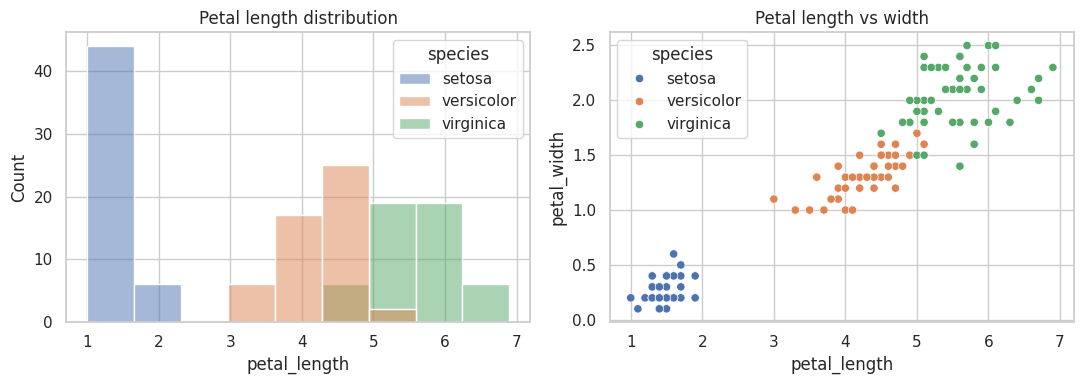

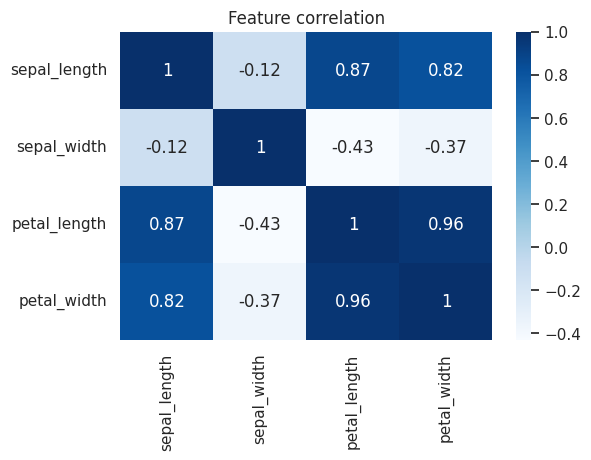

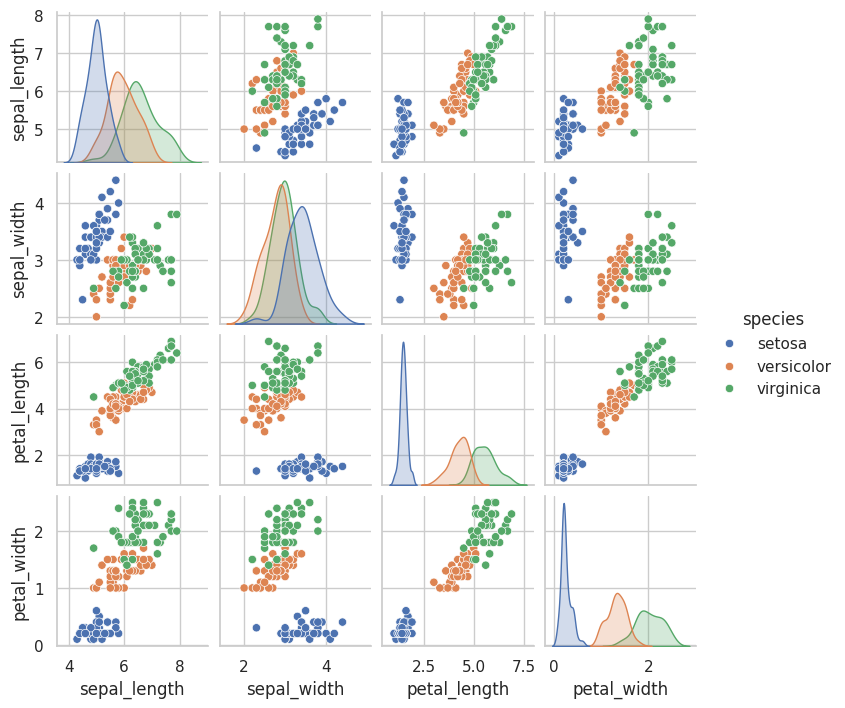

In [6]:
# -----------------------------------------------------------
# 🔹 3A. SUBPLOT COMPARISON (Matplotlib)
# -----------------------------------------------------------
iris = sns.load_dataset('iris')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=iris, x='petal_length', hue='species', ax=axes[0])
axes[0].set_title('Petal length distribution')

sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='species', ax=axes[1])
axes[1].set_title('Petal length vs width')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 🔹 3B. CORRELATION HEATMAP (Seaborn)
# -----------------------------------------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(iris.drop(columns='species').corr(),
            annot=True, cmap='Blues')
plt.title('Feature correlation')
plt.show()

# -----------------------------------------------------------
# 🔹 3C. PAIRPLOT
# -----------------------------------------------------------
sns.pairplot(iris, hue='species', height=1.8)
plt.show()

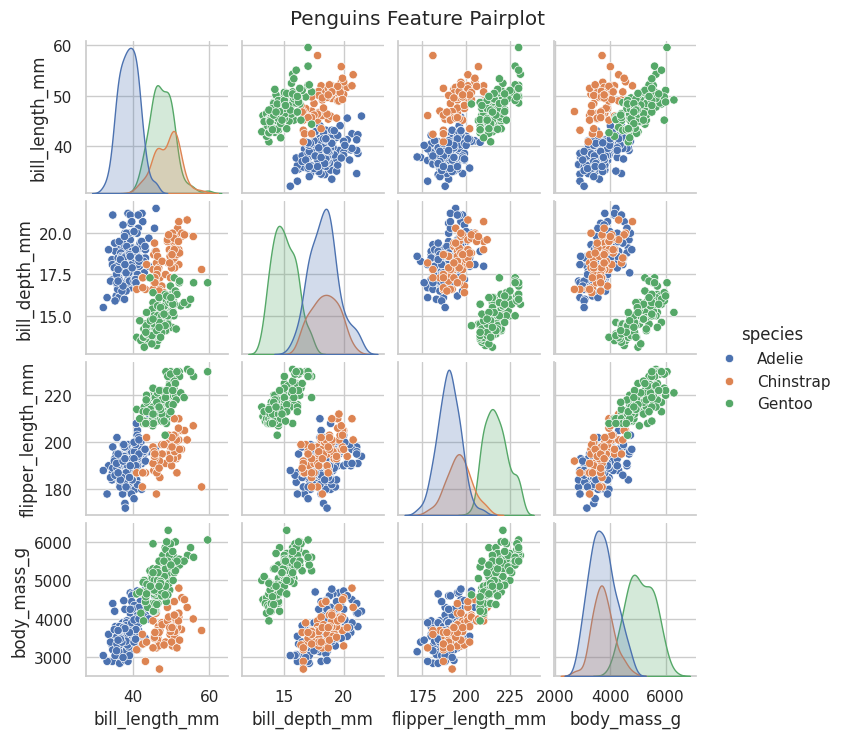

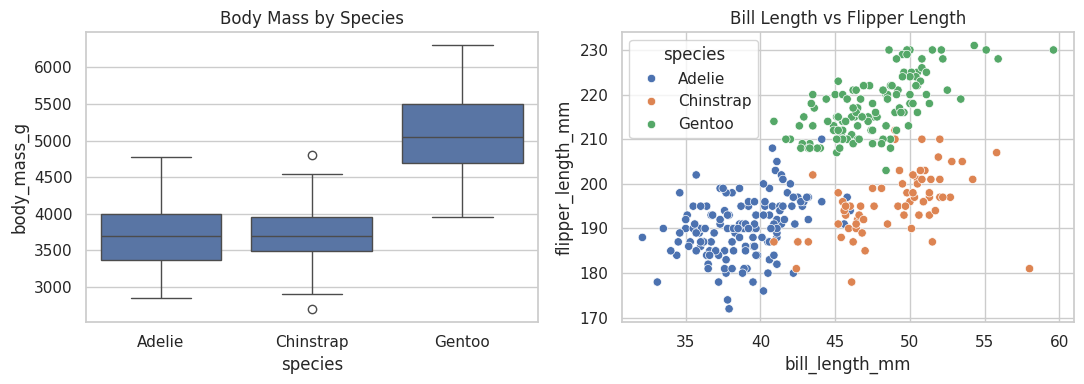

In [7]:
pen = sns.load_dataset('penguins')

# 1. Drop rows with missing values
pen_clean = pen.dropna()

# 2. Pairplot coloured by 'species'
sns.pairplot(pen_clean, hue='species', height=1.8)
plt.suptitle('Penguins Feature Pairplot', y=1.02)
plt.show()

# 3. 1x2 subplot: boxplot (left) + scatter (right)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left plot: boxplot of body_mass_g by species
sns.boxplot(data=pen_clean, x='species', y='body_mass_g', ax=axes[0])
axes[0].set_title('Body Mass by Species')

# Right plot: scatter of bill_length_mm vs flipper_length_mm
sns.scatterplot(data=pen_clean, x='bill_length_mm', y='flipper_length_mm', hue='species', ax=axes[1])
axes[1].set_title('Bill Length vs Flipper Length')

plt.tight_layout()
plt.show()

In [8]:
# -----------------------------------------------------------
# 🔹 4A. LOAD DATA & SPLIT
# -----------------------------------------------------------
X, y = load_iris(return_X_y=True)
print('Features X:', X.shape, '| Target y:', y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape[0], 'samples | Test:', X_test.shape[0], 'samples')

# -----------------------------------------------------------
# 🔹 4B. FIT -> PREDICT -> EVALUATE
# -----------------------------------------------------------
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print('Accuracy:', round(accuracy_score(y_test, pred), 3))
print('Confusion matrix:\n', confusion_matrix(y_test, pred))

# -----------------------------------------------------------
# 🔹 4C. PIPELINE
# -----------------------------------------------------------
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200))
])

pipe.fit(X_train, y_train)
print('Pipeline accuracy:', round(pipe.score(X_test, y_test), 3))

Features X: (150, 4) | Target y: (150,)
Train: 120 samples | Test: 30 samples
Accuracy: 0.9
Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]
Pipeline accuracy: 0.933


In [9]:
Xb, yb = load_breast_cancer(return_X_y=True)
print('Breast cancer data:', Xb.shape)

# 1. train_test_split (test_size=0.25, random_state=0, stratify=yb)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.25, random_state=0, stratify=yb
)

# 2. Build a Pipeline (StandardScaler + a classifier of your choice)
cancer_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=200, random_state=0))
])

# 3. Fit and print the test accuracy
cancer_pipe.fit(Xb_train, yb_train)
accuracy = cancer_pipe.score(Xb_test, yb_test)
print('Test Accuracy:', round(accuracy, 3))

Breast cancer data: (569, 30)
Test Accuracy: 0.958


End-to-end Titanic survival accuracy: 0.793


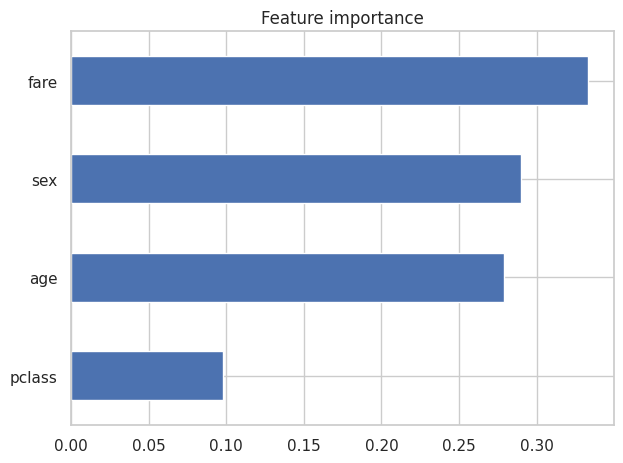

In [10]:
# -----------------------------------------------------------
# 🔹 5. END-TO-END MINI WORKFLOW
# -----------------------------------------------------------
# RAW
data = sns.load_dataset('titanic')

# CLEAN
data = data[['survived', 'pclass', 'sex', 'age', 'fare']].copy()
data['age'] = data['age'].fillna(data['age'].median())
data['sex'] = np.where(data['sex'] == 'male', 0, 1)   # encode to numbers
data = data.dropna()

# SPLIT
X = data.drop(columns='survived').values
y = data['survived'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# MODEL
model = RandomForestClassifier(random_state=42).fit(X_tr, y_tr)
acc = accuracy_score(y_te, model.predict(X_te))

# OUTPUT
print('End-to-end Titanic survival accuracy:', round(acc, 3))

importances = pd.Series(model.feature_importances_,
                        index=data.drop(columns='survived').columns)
importances.sort_values().plot.barh(title='Feature importance')
plt.tight_layout()
plt.show()

In [11]:
# 1. RAW -> Load iris dataset into a DataFrame
iris_df = sns.load_dataset('iris')

# 2. CLEAN / ENCODE -> Separate features and target, encode species to numbers
X_iris = iris_df.drop(columns='species')
# Map category species to numeric labels (0, 1, 2)
y_iris = iris_df['species'].astype('category').cat.codes

# 3. SPLIT -> Train / test split
X_tr_iris, X_te_iris, y_tr_iris, y_te_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# 4. MODEL -> Train a classifier through a pipeline
iris_flow_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])
iris_flow_pipe.fit(X_tr_iris, y_tr_iris)

# 5. OUTPUT -> Evaluate and print accuracy
iris_acc = iris_flow_pipe.score(X_te_iris, y_te_iris)
print('End-to-end Iris Classification Accuracy:', round(iris_acc, 3))

End-to-end Iris Classification Accuracy: 0.9
